-----------------------------
#### Get GPT embeddings 
- for food reviews data

https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
---------------------------

**Load the Dataset:**

- The dataset used in this example is fine-food reviews from Amazon.
- It contains a total of 568,454 food reviews that Amazon users left up to October 2012.
- We will use a subset of this dataset, consisting of the 1,000 most recent reviews for illustration purposes.
- The reviews are in English and tend to be positive or negative.
- Each review has a ProductId, UserId, Score, review title (Summary), and review body (Text).

**Combine Review Summary and Review Text:**

- We will combine the review summary and review text into a single combined text.
- The model will encode this combined text, and it will output a single vector embedding.

In [1]:
import pandas as pd
import numpy as np

In [2]:
location = r'D:\AI-DATASETS\02-MISC-large\GenAI-LLMs\amazon_food_reviews.csv'

In [3]:
df = pd.read_csv(location)

In [4]:
df.shape

(568454, 10)

In [5]:
df.dtypes

Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object

- The dataset contains a total of 568,454 food reviews Amazon users left up to October 2012. 
- We will use a subset of 2,000 most recent reviews for illustration purposes. 
- The reviews are in English and tend to be positive or negative. 
- Each review has a ProductId, UserId, Score, review title (Summary) and review body (Text).

In [6]:
pd.options.display.max_colwidth = None

In [7]:
df[['Summary',	'Text', 'Score']].sample(3)

,Summary,Text,Score
299626,Fresh Iranian Beluga caviar in Istanbul,"In Spring 2008, I bought 2 400 gm tins (that's 14. 1 oz each) for US$86. each.<br /><br />It was almost like doing business with a drug lord, but I figured they could kill me, but not eat me, and they did want some money.<br /><br />Put those in a tiny plastic picnic sac with dry ice and returned (1 to NYC and the second to Mexico).<br /><br />Best thing I have ever tasted and I'm 67.<br /><br />Worth the airfare to Istanbul!!! Great city also.<br /><br />I may still have the merchant's name and addy.<br /><br />ret expat MD",5
555734,So says my spoiled cat:,Absolutely delicious!<br /><br />Ranks right up there with tuna in the excitement category for my 14 year old cat. Wish it were organic.,5
8796,Great glass! Great Tea!,"I was skeptical because I've seen mixed reviews on similar products like this. But I'm glad I jumped in and decided to purchase it. First of all the shipping was fast and it comes gift-wrapped free which is cool. Second, the glass works great which is most important. Its double-walled so when I poured my boiling hot water in the glass I had no problem carrying it from the kitchen to my bedroom and barely feeling any warmth. The filter/strainer does exactly what its supposed to do which is keep the loose tea out of your mouth while you drink your tea. This is the first time I've used something like this and it works perfectly for me.<br /><br />The blooming tea comes in three small containers. I'm new to tea so I can't tell what kind it is...most likely some type of jasmine green tea because it smells good. The first steeping is very mild but the second one the flavor really comes out. Anyway I hope this helps people that are on the fence like I was about buying glasses like this. This package is legit and well worth the price.",5


In [8]:
df.Score.describe()

count    568454.000000
mean          4.183199
std           1.310436
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: Score, dtype: float64

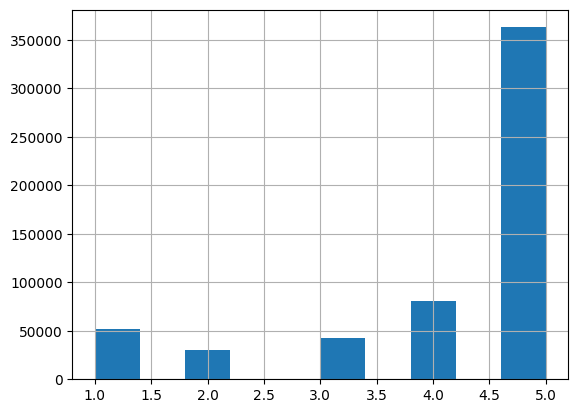

In [9]:
df.Score.hist();

We will combine the review `summary` and review `text` into a single combined text. The model will encode this combined text and it will output a single vector embedding.

In [10]:
df = df[["Time", "ProductId", "UserId", "Score", "Summary", "Text"]]
df = df.dropna()

df["combined"] = (
    "Title: " + df.Summary.str.strip() + "; Content: " + df.Text.str.strip()
)

In [11]:
df.shape

(568427, 7)

In [12]:
# subsample to 2k most recent reviews and remove samples that are too long
top_n = 1000

df    = df.sort_values("Time").tail(top_n * 2)  # first cut to first 2k entries, assuming less than half will be filtered out
df.drop("Time", axis=1, inplace=True)

In [13]:
df.shape

(2000, 6)

In [14]:
df.sample(1)

,ProductId,UserId,Score,Summary,Text,combined
246322,B004MXSHA6,AG4YGLLIE8BWP,5,Makes me drool just thinking of them,"The Brit's have out done us. The flavor is supreme,they satisfy my hunger for steak and onions...<br />Get them while you can... Their other flavors are great tooo","Title: Makes me drool just thinking of them; Content: The Brit's have out done us. The flavor is supreme,they satisfy my hunger for steak and onions...<br />Get them while you can... Their other flavors are great tooo"


In [15]:
df["combined"] = (
    "Title: " + df.Summary.str.strip() + "; Content: " + df.Text.str.strip()
)
df.head(2)

,ProductId,UserId,Score,Summary,Text,combined
467784,B000V1O28Y,A1CHFK7Z8ZJBQ7,4,Better than I thought they would be!,These were actually quite tasty despite the expectation of something bland. What made this dinner a great buy is the thick and meaty portion of chicken breast that comes in it! You really get a nice serving of protein.,Title: Better than I thought they would be!; Content: These were actually quite tasty despite the expectation of something bland. What made this dinner a great buy is the thick and meaty portion of chicken breast that comes in it! You really get a nice serving of protein.
102286,B001QEB3E6,AY2O7I9BNG2UI,4,"Dog loves them, but I hate the smell","I have a 70 pound lab mix, and he goes nuts for these treats. He'll devour one in less than 5 minutes, but it's awesome to see him so happy. However, they have a super strong odor, and I do not find them to be as appealing as he does. Recommended for dog's happiness, just hold your nose if you're sensitive to strong, funky, meat-like smells.","Title: Dog loves them, but I hate the smell; Content: I have a 70 pound lab mix, and he goes nuts for these treats. He'll devour one in less than 5 minutes, but it's awesome to see him so happy. However, they have a super strong odor, and I do not find them to be as appealing as he does. Recommended for dog's happiness, just hold your nose if you're sensitive to strong, funky, meat-like smells."


In [16]:
review = df.combined.sample(3).values

In [17]:
review

array(["Title: Colorado Spice Orange Peel, Fine Cut; Content: It was more then I needed but I'm glad I bought in bulk. This product is as described and saves me the time of removing the pith and cutting the peel myself. I like the flavor the orange adds to my cooking and so do my wife and kids. Thank you for this great time and money saving product.",
       'Title: Hidden Springs Maple syrup; Content: This is one of the very finest maple syrups I have ordered and enjoyed. I bought the Fancy Grade, for the light amber color. It has a very great taste. I will reorder.',
       "Title: Perfect; Content: I have used Sugar Twin most of my life, since my Mom discovered it when I was a child. I do not use any other sugar substitute. There is no after taste or side effects. The calorie free aspect also helps me keep my weight loss going in the correct direction. Sugar Twin stays fresh in the closet as long as it's a dry area.<br />I have not found a local store that carried Sugar Twin so bein

#### About tiktoken

- `tiktoken` is a fast open-source tokenizer by OpenAI. It is used to tokenize text into a sequence of integers that can be processed by OpenAI's GPT models. This is necessary because GPT models do not understand natural language, they only understand sequences of integers.

- Here are some of the benefits of using tiktoken:

    - It is `fast and efficient`. tiktoken is a highly optimized tokenizer that can tokenize text at a high rate. This is important for applications that require real-time processing of text.
    - It is `accurate`. tiktoken produces accurate tokenizations that capture the meaning of the original text. This is important for applications that require high-quality results, such as machine translation and natural language generation.
    - It is `easy to use`. tiktoken has a simple and easy-to-use API that makes it easy to integrate into existing applications.

In [18]:
#!pip install tiktoken

In [19]:
import tiktoken

**Tokenize a text string:**

- tiktoken.get_encoding 
    - function is used to load an encoding by name. 
    - The first time this function is called for a given encoding name, it will download the encoding from the internet. 
    - Later calls will use the cached version of the encoding.
    - The `tiktoken.get_encoding` function takes one argument, which is the encoding name. 
    - The encoding name is a string that identifies the encoding. 
        - For example, the encoding name "cl100k_base" identifies the BPE encoding that was trained on the cl100k dataset.
        
- The `tiktoken.get_encoding` function returns an Encoding object. 
    - The Encoding object has the following methods:

        - `encode`(text): Encodes a text string into a sequence of integers.
        - `decode`(tokens): Decodes a sequence of integers into a text string.
        - `vocab_size()`: Returns the size of the vocabulary.
        - `eos()`: Returns the ID of the end-of-sentence token.
        - `pad()`: Returns the ID of the pad token.

In [20]:
# To get the tokeniser corresponding to a specific model in the OpenAI API:
enc = tiktoken.encoding_for_model("gpt-4")
enc

<Encoding 'cl100k_base'>

In [21]:
enc = tiktoken.encoding_for_model("gpt-3.5-turbo")
enc

<Encoding 'cl100k_base'>

In [22]:
# # this the encoding for text-embedding-ada-002
encoding = tiktoken.get_encoding("cl100k_base")

tokens   = encoding.encode("This is a text string at doddaballapura road.")
print(tokens)

[2028, 374, 264, 1495, 925, 520, 294, 14898, 370, 543, 391, 5808, 5754, 13]


**Decode a sequence of tokens**

In [23]:
text = encoding.decode(tokens)
print(text)

This is a text string at doddaballapura road.


In [24]:
num_tokens = len(tokens)
print(num_tokens)

14


... back to code

In [25]:
import os
import openai
from openai import OpenAI

In [26]:
# embedding model parameters
embedding_model    = "text-embedding-3-small" # smallest
embedding_encoding = "cl100k_base"  # this the encoding for text-embedding-ada-002

max_tokens         = 8000  # the maximum for text-embedding-ada-002 is 8191

In [27]:
encoding = tiktoken.get_encoding(embedding_encoding)

In [28]:
# get the number of tokens for each sample ('combined')
df["n_tokens"] = df.combined.apply(lambda x: len(encoding.encode(x)))

In [29]:
df.sample(2)

,ProductId,UserId,Score,Summary,Text,combined,n_tokens
4412,B003SWCZG4,A2WJH1QD0M9X51,5,Chocolate is good for you!! Eat more.,"Many reports are coming out about how chocolate is actually good for you, so eat more! This is the perfect chocolate to do that with. The varying levels of cocoa are perfect to help adjust your taste buds to eating dark, dark chocolate. It's not an easy transition for a milk/semi-sweet kinda gal, but this chocolate is affordable and so tasty. I also like that I can just have one (as they are individually wrapped), and choose my %.","Title: Chocolate is good for you!! Eat more.; Content: Many reports are coming out about how chocolate is actually good for you, so eat more! This is the perfect chocolate to do that with. The varying levels of cocoa are perfect to help adjust your taste buds to eating dark, dark chocolate. It's not an easy transition for a milk/semi-sweet kinda gal, but this chocolate is affordable and so tasty. I also like that I can just have one (as they are individually wrapped), and choose my %.",110
137325,B001P05K7W,A12K29KCD2VNDS,5,Keeps my dog's mouth clean!,These chews do an excellent job of keeping my dog's mouth clean. He loves the way they taste too! The vet even commented on how good his teeth look. He does not get his teeth brushed; we only use the chews to clean his teeth.,Title: Keeps my dog's mouth clean!; Content: These chews do an excellent job of keeping my dog's mouth clean. He loves the way they taste too! The vet even commented on how good his teeth look. He does not get his teeth brushed; we only use the chews to clean his teeth.,65


<Axes: >

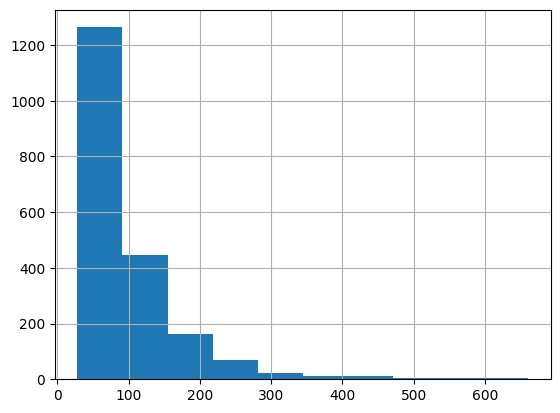

In [30]:
df.n_tokens.hist()

In [31]:
# number of samples with number of tokens more than max_tokens
df[df.n_tokens > 250].sample(2)

,ProductId,UserId,Score,Summary,Text,combined,n_tokens
96531,B0076YVPFC,A3OJX18B60PJR9,4,"Tasty & convenient but at $3.21 a package, not the best value available","Daverat's Wife speaking: I made this for my husband and it was very easy to prepare in the microwave. He enjoyed the meal and stated that he'd love to have them on hand if the price point was more reasonable. He ate his Fusilla & Veg Marinara with a large salad seasoned only with some balsamic vingar and had it for his dinner meal. To use the Chinese food cliche, he told me an hour later he was hungry again so I made him a grilled chicken breast. That got me to thinking that the packaged meal alone wouldn't work for us as a stand-alone meal. We'd have to add to it for it to work. If these were a dollar per package cheaper after Subscribe & Save, they might make a good shelf stable meal to which you could add cooked chicken strips, canned chicken, black beans or even a high quality pouched tuna. On it's own, it's not filling enough nor nutritionally complete.<br /><br />Right at this moment, Amazon is showing me an offer for a $5 off Amazon coupon which when applied, brings the price point after Subscribe & Save down to $2.38, which is quite a bit better and rather tempting. However, after seeing this, I asked my husband if he wanted me to order some for the pantry and suddenly he wasn't as in love with the product any more. Oh well! When you add in the cost of a small salad plus some lean protein such as the gilled chicken breast, even with the $5 off, it brings the per meal cost back up to around $4.60. That may sound like a bargain if you eat out often or grab fast food a few nights a week but we don't. I plan our meals out for the week and even sometimes for an entire month ahead of time to get the most from every grocery item we buy and I could make this same dish using Barilla High protein pasta, my own vegetable marinara with veg from my gardens and come out quite a bit cheaper. I also think I could eliminate some of the high sodium contant and bring down the fat in the dish as well.<br /><br />I gave it four stars, however, because hubby liked it, it was simple to prepare and even a starving teenager can toss in some chicken strips of canned chicken to make it a more filling meal. There's enough sauce in the meal to coat a moderate amount of added chicken or meat. I could see this being a good pantry staple for a college student or a busy single person. As shelf-stable meals go, even though I wasn't all that impressed with the sodium count and fat, this brand compares quite favorable with other shelf-stable meals. It could be a good choice for folks in ned of something o brag and nuke quickly at the end of a long day and in place of ordering in restaurant food. For a family on a budget.. not so much of a deal.","Title: Tasty & convenient but at $3.21 a package, not the best value available; Content: Daverat's Wife speaking: I made this for my husband and it was very easy to prepare in the microwave. He enjoyed the meal and stated that he'd love to have them on hand if the price point was more reasonable. He ate his Fusilla & Veg Marinara with a large salad seasoned only with some balsamic vingar and had it for his dinner meal. To use the Chinese food cliche, he told me an hour later he was hungry again so I made him a grilled chicken breast. That got me to thinking that the packaged meal alone wouldn't work for us as a stand-alone meal. We'd have to add to it for it to work. If these were a dollar per package cheaper after Subscribe & Save, they might make a good shelf stable meal to which you could add cooked chicken strips, canned chicken, black beans or even a high quality pouched tuna. On it's own, it's not filling enough nor nutritionally complete.<br /><br />Right at this moment, Amazon is showing me an offer for a $5 off Amazon coupon which when applied, brings the price point after Subscribe & Save down to $2.38, which is quite a bit better and rather

In [32]:
# number of samples with number of tokens less than max_tokens
df[df.n_tokens <= max_tokens].shape

(2000, 7)

#### Get embeddings and save them for future reuse
- Ensure you have your API key set in your environment

In [34]:
from openai import OpenAI

client = openai.OpenAI()

In [35]:
def get_embedding(text, model="text-embedding-3-small"):
    text = text.replace("\n", " ")
    return client.embeddings.create(input = [text], model=model).data[0].embedding

In [36]:
df.shape

(2000, 7)

In [40]:
%%time
# This may take a few minutes (10 - 20 mins)
# df['ada_embedding'] = df.combined.apply(lambda x: get_embedding(x, model='text-embedding-3-small'))

CPU times: total: 7.95 s
Wall time: 15min 47s


#### Options for faster obtaining of embeddings

**Option 1** - Batch Processing
- This reduces the overhead associated with making individual API calls and can significantly reduce the total time required.

In [37]:
def get_embeddings_batch(texts, model='text-embedding-3-small'):
    # Using the client to create embeddings
    response = client.embeddings.create(input=texts, model=model)
    
    # Extract embeddings from the response
    return [embedding.embedding for embedding in response.data]

In [38]:
batch_size = 50  # Adjust based on API limits and memory, 50, 100, 150 ...
embeddings = []

In [39]:
%%time
for i in range(0, len(df), batch_size):
    
    batch = df.combined[i:i+batch_size].tolist()
    
    embeddings.extend(get_embeddings_batch(batch))

df['ada_embedding'] = embeddings

CPU times: total: 1.33 s
Wall time: 1min 13s


**Option 2** - Parallel Processing with Threading:
- Using multiple threads can help make API calls concurrently, thus utilizing available resources more efficiently.

In [40]:
from concurrent.futures import ThreadPoolExecutor

In [41]:
def get_embeddings_batch(texts, model='text-embedding-3-small'):
    # Using the client to create embeddings
    response = client.embeddings.create(input=texts, model=model)
    
    # Extract embeddings from the response
    return [embedding.embedding for embedding in response.data]

In [42]:
def process_batch(batch):
    return get_embeddings_batch(batch)

In [43]:
batch_size = 50  # Adjust based on API limits and memory
embeddings = []

In [45]:
# Number of threads to use. Adjust based on your system's capabilities
max_workers = 10

In [46]:
%%time
with ThreadPoolExecutor(max_workers=max_workers) as executor:
    
    # Split the data into batches and process them in parallel
    batches = [df.combined[i:i+batch_size].tolist() for i in range(0, len(df), batch_size)]
    results = executor.map(process_batch, batches)
    
    # Flatten the list of lists into a single list of embeddings
    embeddings = [embedding for batch_result in results for embedding in batch_result]

CPU times: total: 1.06 s
Wall time: 18.7 s


In [47]:
# Add the embeddings to the DataFrame
df['ada_embedding'] = embeddings

In [48]:
df.sample(1)

,ProductId,UserId,Score,Summary,Text,combined,n_tokens,ada_embedding
408943,B008ADQOL8,A1YYFX661KECLP,5,Incredible matcha!,This matcha is incredible - I got hooked on plain matcha - so having someone kick it up a notch and add this incredible flavour is amazing. I'm a big Boston Cream donut fan and this has the same taste too it. Highly recommend it!,Title: Incredible matcha!; Content: This matcha is incredible - I got hooked on plain matcha - so having someone kick it up a notch and add this incredible flavour is amazing. I'm a big Boston Cream donut fan and this has the same taste too it. Highly recommend it!,63,"[-0.001759743201546371, -0.025993043556809425, -0.025086458772420883, -0.003334932029247284, 0.011766158044338226, -0.02469792403280735, -0.02083846740424633, 0.06361625343561172, 0.03364719823002815, -0.035822998732328415, 0.03947523236274719, 0.0008377802441827953, 0.006090298295021057, 0.017393451184034348, 0.007194387260824442, 0.030538910999894142, -0.030331691727042198, -0.03636694699525833, 0.029036572203040123, 0.05796953663229942, 0.018572010099887848, 0.031393688172101974, 0.02380429208278656, 0.04592492803931236, 0.034553781151771545, 0.009357236325740814, -0.034087538719177246, -0.0357452891767025, 0.034735098481178284, -0.026731260120868683, -0.0010126213310286403, -0.005371506791561842, -0.016098331660032272, -0.06853771209716797, 0.032067153602838516, -0.032481588423252106, 0.01213526725769043, 0.021421272307634354, -0.006987167987972498, -0.01956925168633461, 0.016240794211626053, 0.005737378261983395, 0.05009521171450615, 0.03185993432998657, -0.019957786425948143, -0.0013372106477618217, -0.004273893311619759, -0.02083846740424633, -0.041702840477228165, 0.020734859630465508, 0.0021078065037727356, 0.0771372988820076, -0.03043530136346817, 0.0070065949112176895, 0.03178222477436066, -0.027456527575850487, -0.01797625422477722, 0.05729607492685318, -0.0071879117749631405, -0.004089339170604944, 0.02945101074874401, -0.028440818190574646, -0.005297037772834301, 0.01980237290263176, -0.025565654039382935, -0.10143373906612396, -0.0051221963949501514, -0.04289434850215912, 0.003006295533850789, 0.0324556864798069, 0.02168029546737671, 0.003245892468839884, -0.06439332664012909, -0.02003549411892891, 0.001636706874705851, 0.0025805251207202673, -0.004834032617509365, 0.0011696545407176018, -0.05133852735161781, -0.060611579567193985, -0.047168243676424026, 0.015981771051883698, -0.05460222810506821, -0.02214653789997101, 0.03846504166722298, -0.012847582809627056, -0.0038983088452368975, -0.04294615238904953, -0.03072022832930088, 0.008871566504240036, -0.0024736777413636446, -0.015787502750754356, -0.01924547180533409, -0.0014472957700490952, 0.016629330813884735, 0.05874660611152649, -0.027715550735592842, 0.040433622896671295, 0.009512650780379772, 0.019167764112353325, ...]"


In [49]:
save_file_path = r'D:\AI-DATASETS\02-MISC-large\GenAI-LLMs\amazon_food_reviews_with_embeddings_2k.csv'
df.to_csv(save_file_path)

To load the data from a saved file, you can run the following:

In [50]:
df_loaded = pd.read_csv(save_file_path)
df_loaded['ada_embedding'] = df_loaded.ada_embedding.apply(eval).apply(np.array)